# About the Dataset
## Understanding the Student Performance Datasets

The datasets are: `student-mat.csv` and `student-por.csv`. They represent a particular study of two Portuguese secondary schools (**Gabriel Pereira** and **Mousinho da Silveira**). The dataset was gotten from UCI Machine Learning Repository, an open-source datasets repository.

Here’s a breakdown of what the data entail.

---

### 1. The Subject Matter Split
The core difference between the two files is simply the **academic subject** being tracked:
* **`student-mat.csv`**: Tracks the students' performance in the **Mathematics** course.
* **`student-por.csv`**: Tracks the students' performance in the **Portuguese Language** course.

### 2. The Grade "Ladder" ($G1 \rightarrow G2 \rightarrow G3$)
In Portugal, grades are recorded on a **0–20 scale**, which is the standard. You’ll notice three distinct grade columns:
* **G1 & G2**: These are mid-term checkpoints.
* **G3**: This is the **final grade**, the target variable.

### Student Performance Data Dictionary

| Column | Description | Values / Range |
| :--- | :--- | :--- |
| **school** | Student's school | "GP" (Gabriel Pereira), "MS" (Mousinho da Silveira) |
| **sex** | Student's sex | "F" (female), "M" (male) |
| **age** | Student's age | 15 to 22 |
| **address** | Home address type | "U" (urban), "R" (rural) |
| **famsize** | Family size | "LE3" (<=3), "GT3" (>3) |
| **Pstatus** | Parent's status | "T" (together), "A" (apart) |
| **Medu** | Mother's education | 0: none, 1: 4th grade, 2: 5th-9th, 3: secondary, 4: higher |
| **Fedu** | Father's education | 0: none, 1: 4th grade, 2: 5th-9th, 3: secondary, 4: higher |
| **Mjob** | Mother's job | "teacher", "health", "services", "at_home", "other" |
| **Fjob** | Father's job | "teacher", "health", "services", "at_home", "other" |
| **reason** | Reason for school | "home", "reputation", "course", "other" |
| **guardian** | Student's guardian | "mother", "father", "other" |
| **traveltime** | Travel time | 1: <15m, 2: 15-30m, 3: 30m-1h, 4: >1h |
| **studytime** | Weekly study time | 1: <2h, 2: 2-5h, 3: 5-10h, 4: >10h |
| **failures** | Past class failures | n if 1<=n<3, else 4 |
| **schoolsup** | Extra educational support | yes, no |
| **famsup** | Family educational support | yes, no |
| **paid** | Extra paid classes | yes, no |
| **activities** | Extra-curriculars | yes, no |
| **nursery** | Attended nursery | yes, no |
| **higher** | Wants higher ed | yes, no |
| **internet** | Home internet | yes, no |
| **romantic** | In a relationship | yes, no |
| **famrel** | Family relationship | 1 (very bad) to 5 (excellent) |
| **freetime** | Free time | 1 (very low) to 5 (very high) |
| **goout** | Socializing | 1 (very low) to 5 (very high) |
| **Dalc** | Workday alcohol | 1 (very low) to 5 (very high) |
| **Walc** | Weekend alcohol | 1 (very low) to 5 (very high) |
| **health** | Health status | 1 (very bad) to 5 (very good) |
| **absences** | School absences | 0 to 93 |
| **G1** | First period grade | 0 to 20 |
| **G2** | Second period grade | 0 to 20 |
| **G3** | Final grade | 0 to 20 (Target) |

### Import Libraries

In [120]:
# Data manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning models
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

# Save trained model
import joblib

# Filter Warning
import warnings
warnings.filterwarnings('ignore')

In [72]:
# Upload files
from google.colab import files
uploaded = files.upload()

Saving student-por.csv to student-por (1).csv
Saving student-mat.csv to student-mat (1).csv


### Load datasets

In [121]:
# Load mathematics dataset
mat = pd.read_csv("student-mat.csv", sep=";")

# Load Portuguese dataset
por = pd.read_csv("student-por.csv", sep=";")

# Preview
mat.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [122]:
mat.shape

(395, 33)

In [123]:
# Preview
por.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,4,0,11,11
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,2,9,11,11
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,6,12,13,12
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,0,14,14,14
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,0,11,13,13


In [124]:
por.shape

(649, 33)

### Merge the Datasets

In [125]:
# Let's merge the dataset using shared identifying attributes

merged = pd.merge(mat, por, on=["school","sex","age","address","famsize","Pstatus",
                                 "Medu","Fedu","Mjob","Fjob","reason","nursery",
                                 "internet"
                                ],
                                suffixes=("_mat","_por")
                  )

merged.shape

(382, 53)

In [126]:
merged.head(10)

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel_por,freetime_por,goout_por,Dalc_por,Walc_por,health_por,absences_por,G1_por,G2_por,G3_por
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,4,0,11,11
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,2,9,11,11
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,6,12,13,12
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,0,14,14,14
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,0,11,13,13
5,GP,M,16,U,LE3,T,4,3,services,other,...,5,4,2,1,2,5,6,12,12,13
6,GP,M,16,U,LE3,T,2,2,other,other,...,4,4,4,1,1,3,0,13,12,13
7,GP,F,17,U,GT3,A,4,4,other,teacher,...,4,1,4,1,1,1,2,10,13,13
8,GP,M,15,U,LE3,A,3,2,services,other,...,4,2,2,1,1,1,0,15,16,17
9,GP,M,15,U,GT3,T,3,4,other,other,...,5,5,1,1,1,5,0,12,12,13


In [127]:
merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 382 entries, 0 to 381
Data columns (total 53 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   school          382 non-null    object
 1   sex             382 non-null    object
 2   age             382 non-null    int64 
 3   address         382 non-null    object
 4   famsize         382 non-null    object
 5   Pstatus         382 non-null    object
 6   Medu            382 non-null    int64 
 7   Fedu            382 non-null    int64 
 8   Mjob            382 non-null    object
 9   Fjob            382 non-null    object
 10  reason          382 non-null    object
 11  guardian_mat    382 non-null    object
 12  traveltime_mat  382 non-null    int64 
 13  studytime_mat   382 non-null    int64 
 14  failures_mat    382 non-null    int64 
 15  schoolsup_mat   382 non-null    object
 16  famsup_mat      382 non-null    object
 17  paid_mat        382 non-null    object
 18  activities

### Create Target Variable (At-Risk)

In [128]:
# Compute average final grade across subjects in the merged dataset

merged["G3_avg"] = (merged["G3_mat"] + merged["G3_por"]) / 2

# Define classification label

merged["risk"] = merged["G3_avg"].apply(lambda x: 1 if x < 10 else 0)

merged["risk"].value_counts()

,count
risk,
0,283
1,99


In [129]:
merged.head(10)

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,goout_por,Dalc_por,Walc_por,health_por,absences_por,G1_por,G2_por,G3_por,G3_avg,risk
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,1,1,3,4,0,11,11,8.5,1
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,3,1,1,3,2,9,11,11,8.5,1
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,2,2,3,3,6,12,13,12,11.0,0
3,GP,F,15,U,GT3,T,4,2,health,services,...,2,1,1,5,0,14,14,14,14.5,0
4,GP,F,16,U,GT3,T,3,3,other,other,...,2,1,2,5,0,11,13,13,11.5,0
5,GP,M,16,U,LE3,T,4,3,services,other,...,2,1,2,5,6,12,12,13,14.0,0
6,GP,M,16,U,LE3,T,2,2,other,other,...,4,1,1,3,0,13,12,13,12.0,0
7,GP,F,17,U,GT3,A,4,4,other,teacher,...,4,1,1,1,2,10,13,13,9.5,1
8,GP,M,15,U,LE3,A,3,2,services,other,...,2,1,1,1,0,15,16,17,18.0,0
9,GP,M,15,U,GT3,T,3,4,other,other,...,1,1,1,5,0,12,12,13,14.0,0


In [130]:
merged["risk"].head(10)

,risk
0,1
1,1
2,0
3,0
4,0
5,0
6,0
7,1
8,0
9,0


#### Interpretation:
1 = At-risk \
0 = Not-at-risk

Here, At-risk (1) and Not-at-risk (0) are the target variables that we want to use to predict student performance in this project.

## Data Cleaning and Preprocessing

### Identify Missing Values

In [131]:
# identifying missing values

merged.isnull().sum()

,0
school,0
sex,0
age,0
address,0
famsize,0
Pstatus,0
Medu,0
Fedu,0
Mjob,0
Fjob,0


**Comment**: We have no missing value in the merged dataset.

### Check for Duplicate Rows

In [132]:
# Checking for duplicate rows

merged.duplicated().sum()

np.int64(0)

**Comment**: There are no duplicate rows in the dataset.

In [133]:
merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 382 entries, 0 to 381
Data columns (total 55 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   school          382 non-null    object 
 1   sex             382 non-null    object 
 2   age             382 non-null    int64  
 3   address         382 non-null    object 
 4   famsize         382 non-null    object 
 5   Pstatus         382 non-null    object 
 6   Medu            382 non-null    int64  
 7   Fedu            382 non-null    int64  
 8   Mjob            382 non-null    object 
 9   Fjob            382 non-null    object 
 10  reason          382 non-null    object 
 11  guardian_mat    382 non-null    object 
 12  traveltime_mat  382 non-null    int64  
 13  studytime_mat   382 non-null    int64  
 14  failures_mat    382 non-null    int64  
 15  schoolsup_mat   382 non-null    object 
 16  famsup_mat      382 non-null    object 
 17  paid_mat        382 non-null    obj

### Remove Data Leakage Features

In [134]:
# Remove intermediate grades

merged.drop(
    ["G1_mat","G2_mat","G3_mat","G1_por","G2_por","G3_por","G3_avg"],
    axis=1,
    inplace=True
)

These variables that we just dropped strongly correlate with final grades and artificially inflate model accuracy.

In [135]:
merged.head(10)

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,higher_por,romantic_por,famrel_por,freetime_por,goout_por,Dalc_por,Walc_por,health_por,absences_por,risk
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,yes,no,4,3,4,1,1,3,4,1
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,yes,no,5,3,3,1,1,3,2,1
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,yes,no,4,3,2,2,3,3,6,0
3,GP,F,15,U,GT3,T,4,2,health,services,...,yes,yes,3,2,2,1,1,5,0,0
4,GP,F,16,U,GT3,T,3,3,other,other,...,yes,no,4,3,2,1,2,5,0,0
5,GP,M,16,U,LE3,T,4,3,services,other,...,yes,no,5,4,2,1,2,5,6,0
6,GP,M,16,U,LE3,T,2,2,other,other,...,yes,no,4,4,4,1,1,3,0,0
7,GP,F,17,U,GT3,A,4,4,other,teacher,...,yes,no,4,1,4,1,1,1,2,1
8,GP,M,15,U,LE3,A,3,2,services,other,...,yes,no,4,2,2,1,1,1,0,0
9,GP,M,15,U,GT3,T,3,4,other,other,...,yes,no,5,5,1,1,1,5,0,0


### Outlier Detection And Treatment

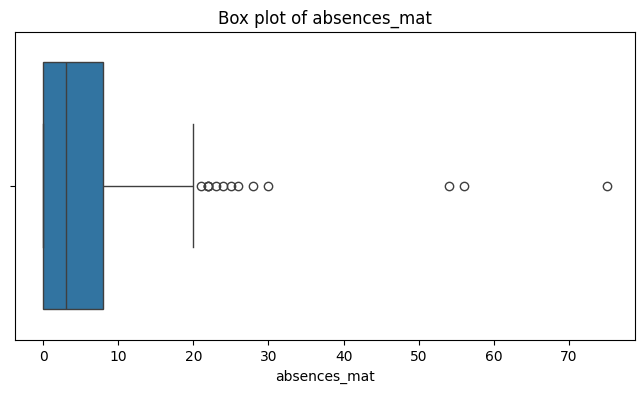

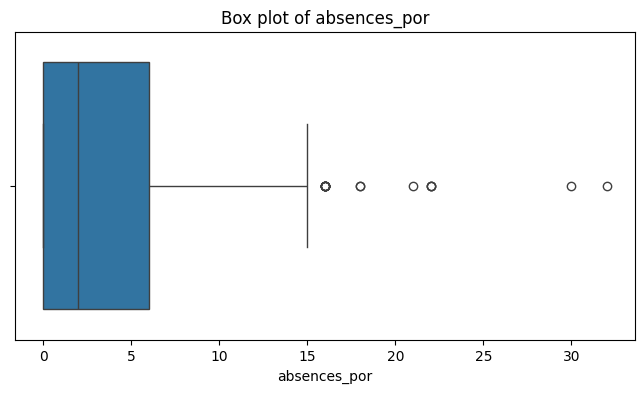

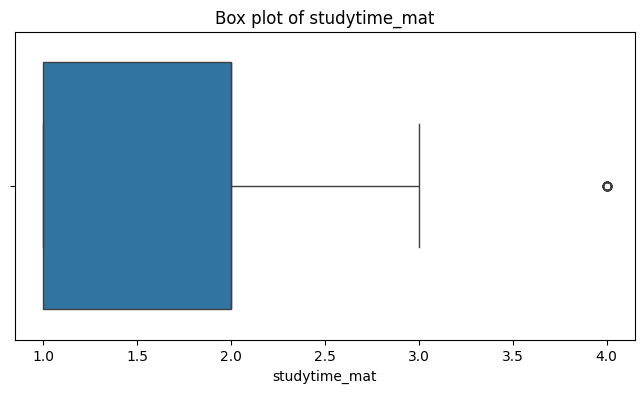

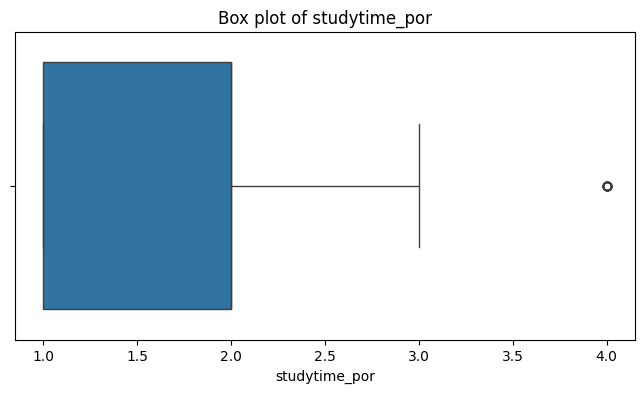

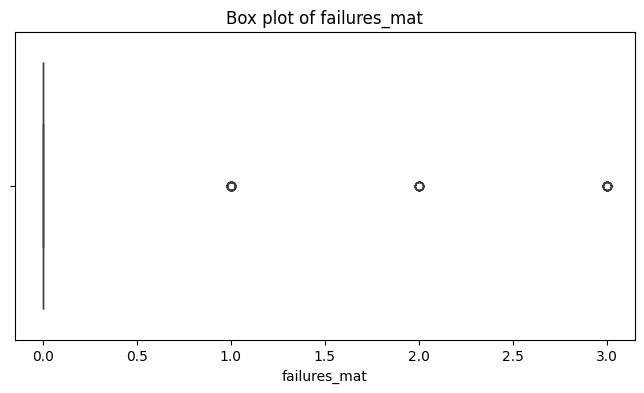

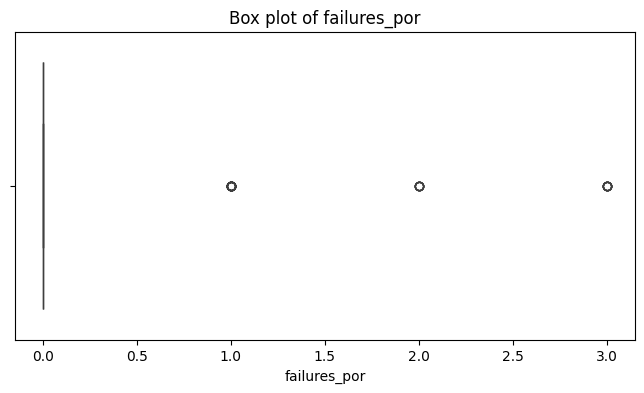

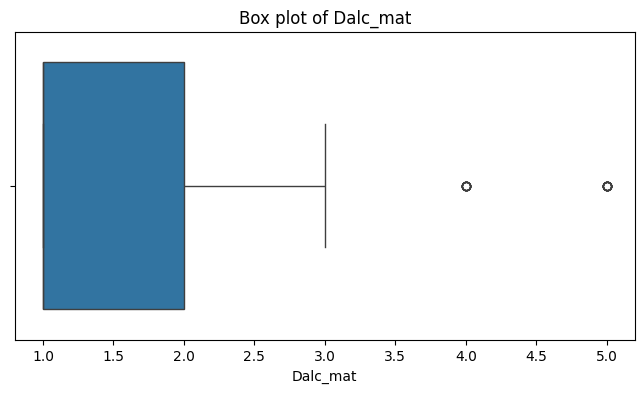

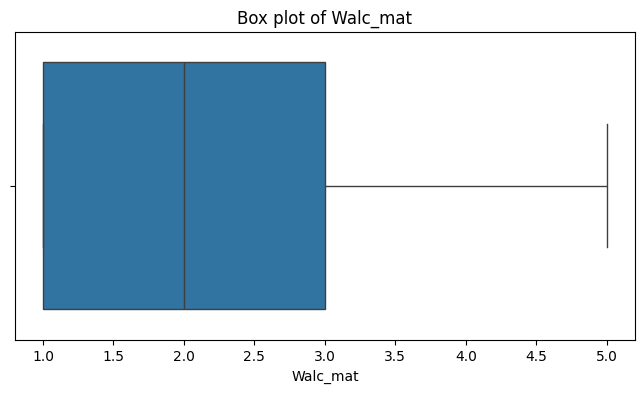

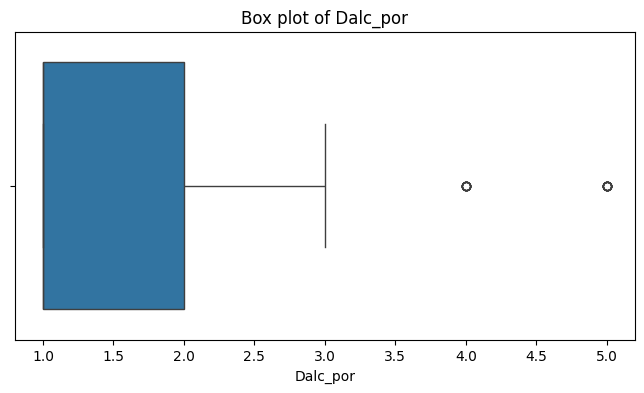

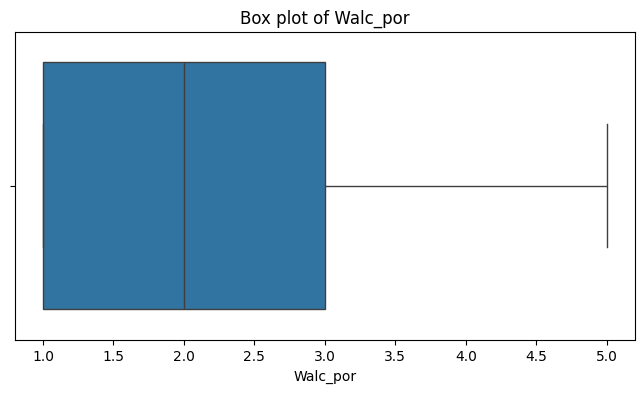

In [136]:
# Detecting outliers on "absences, studytime, failures,
# and alcohol consumption" variables

# store the features in a variable
columns = [
    'absences_mat', 'absences_por',
    'studytime_mat', 'studytime_por',
    'failures_mat', 'failures_por',
    'Dalc_mat', 'Walc_mat', 'Dalc_por', 'Walc_por'
]

# Loop through the columns to plot the boxplots
for col in columns:
    plt.figure(figsize=(8, 4)) # Create a new figure for each plot
    sns.boxplot(x=merged[col])
    plt.title(f'Box plot of {col}')
    plt.xlabel(col)
    plt.show()

#### Interpretation:
We've checked and detected no outlier that may skew the model's predictive accuracy. Now, We have a clean dataset to work with.

## Exploratory Data Analysis (EDA)

### Univariate Analysis (Single Variable Analysis)

The purpose is to understand the distribution of each feature.

#### **Target Variable Distribution**
This distribution shows the imbalance between `At-risk` vs `Not-at-risk` students.



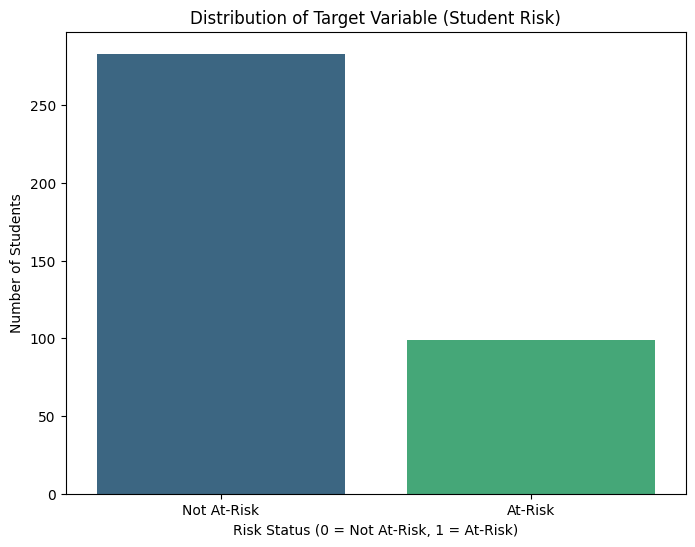

In [137]:
# Target variable distribution plot

plt.figure(figsize=(8, 6))
sns.countplot(x='risk', data=merged, palette='viridis')
plt.title('Distribution of Target Variable (Student Risk)')
plt.xlabel('Risk Status (0 = Not At-Risk, 1 = At-Risk)')
plt.ylabel('Number of Students')
plt.xticks([0, 1], ['Not At-Risk', 'At-Risk'])
plt.show()

**Comment**: `Not-At-Risk` students are 293 in numbers while `At-Risk` students are 99 in numbers. There are more students who are academically stable than those who needs early intervention.

#### **Age Distribution**

<Axes: xlabel='age', ylabel='Count'>

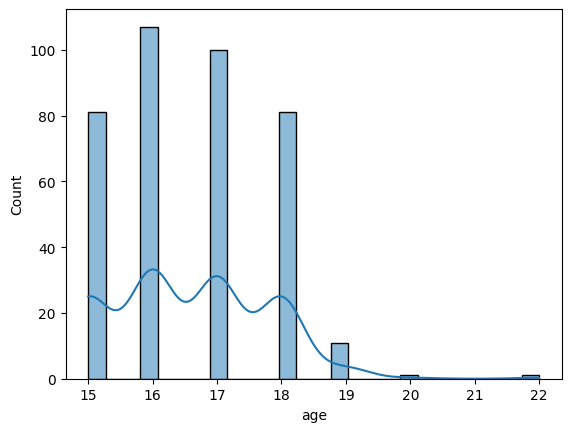

In [138]:
# Age Distribution using Histogram Plot

sns.histplot(merged["age"], kde=True)

### Age Distribution Interpretation

With the use of the histogram and the Kernel Density Estimate (KDE), there is an illustration of the age distribution in the student dataset, which can be interpreted as follows:

- Age Cluster: There is an age cluster in the dataset that is mostly represented by the core secondary school age group, particularly those aged between 15 and 18.
- Most Common Age: With regard to the bars' height and the highest point of the KDE graph, the age group or age of the majority of students can be determined.
- Range: The tail end of the graph indicates that there are some younger and older students, thus providing an overview of the age distribution of the students.

Implications:

- Resource Allocation: Resources can be allocated effectively for students based on their ages.

#### **Absences Distribution**

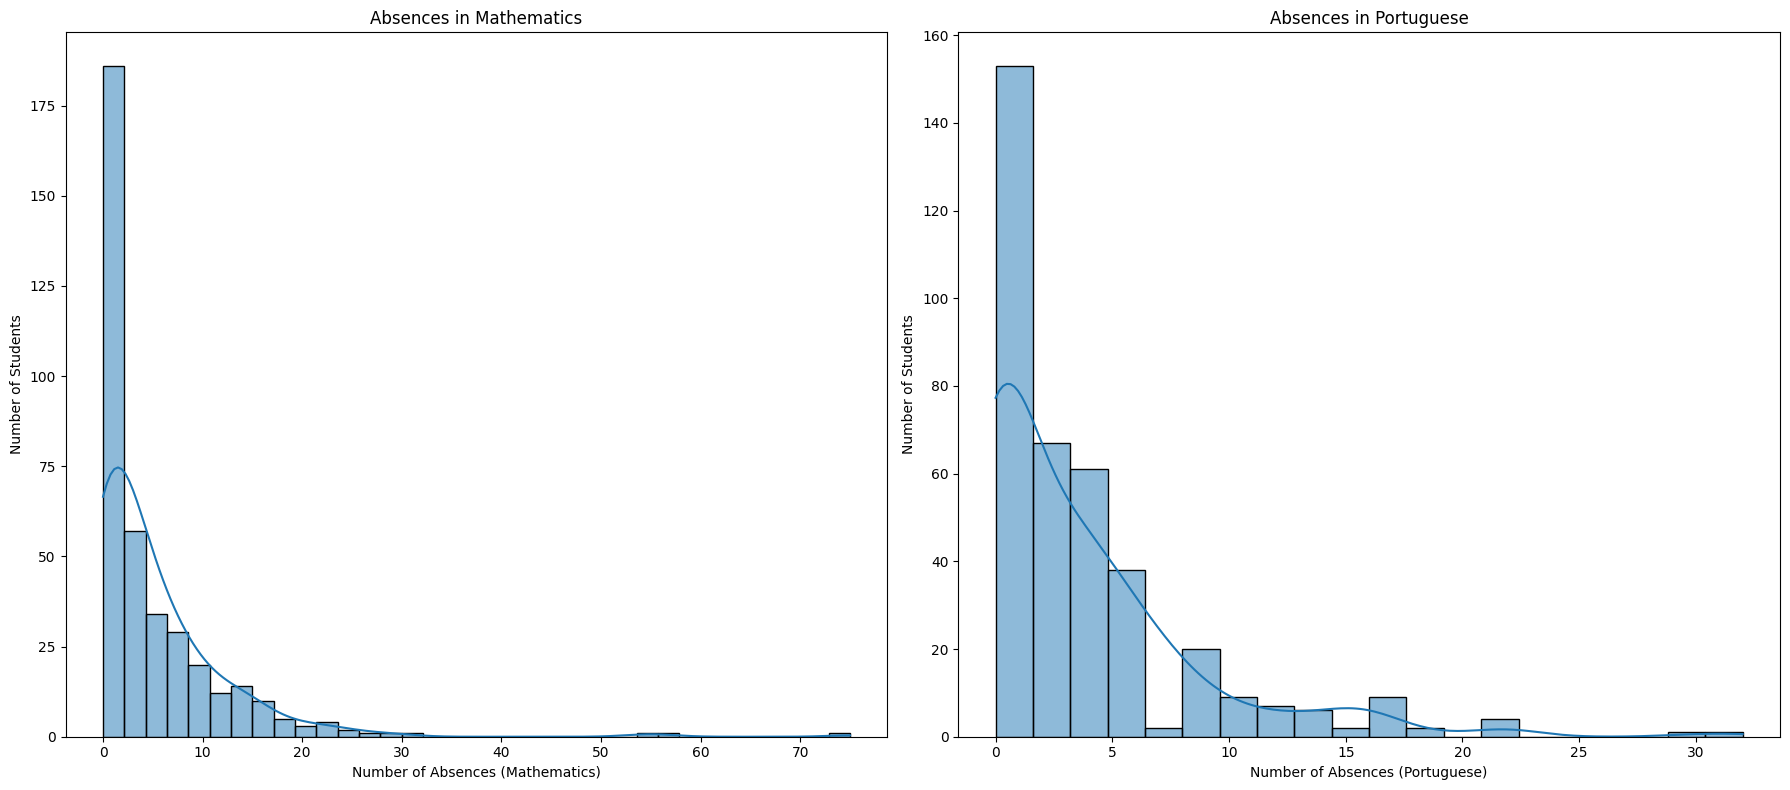

In [139]:
# Absences Distribution using Histplot

plt.figure(figsize=(18, 8))

plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
sns.histplot(merged["absences_mat"], kde=True)
plt.title('Absences in Mathematics')
plt.xlabel('Number of Absences (Mathematics)')
plt.ylabel('Number of Students')

plt.subplot(1, 2, 2) # plotting the 'absences_por' on the second column
sns.histplot(merged["absences_por"], kde=True)
plt.title('Absences in Portuguese')
plt.xlabel('Number of Absences (Portuguese)')
plt.ylabel('Number of Students')

plt.tight_layout() # This adjusts subplot parameters for a tight layout
plt.show()

### Interpretation of Distribution of Absences

Histograms enriched with Kernel Density Estimates (KDEs) show the distribution of student absences for Math and Portuguese lessons. The following points can be identified:

- The right-skewed distribution: It is obvious that the distribution of absences is right-skewed. Thus, the largest proportion of students experiences a small number of absences with the right tail consisting of a much smaller portion of students who have much more absence cases.
- Absences below the mode: Peaks for both Math and Portuguese lessons are located within a low level of absences (between 0-5).
- Presence of high-absence students: However, there are still significant numbers of high-absence students despite a large number of low-absence students.

### Insights for Stakeholders:

- Targeting: According to the distribution observed, a special approach is required. Instead of taking care of all students, one needs to target those who have more absences to identify the reasons why they have such attendance records and to find out ways to address the problem.
- Identification of reasons for absences: One should identify the reasons for absences (illness, problems at home, lack of motivation, etc.) and find out ways to solve these issues.
- Promotion of regular attendance: In addition, one should promote attendance among students via campaigns or any other methods because attendance affects educational achievements.
- Monitoring of high absence students: As a rule, students with high attendance records perform worse than others. Therefore, one should monitor their progress in learning and assist them with catching up.

#### **Study Time Distribution**

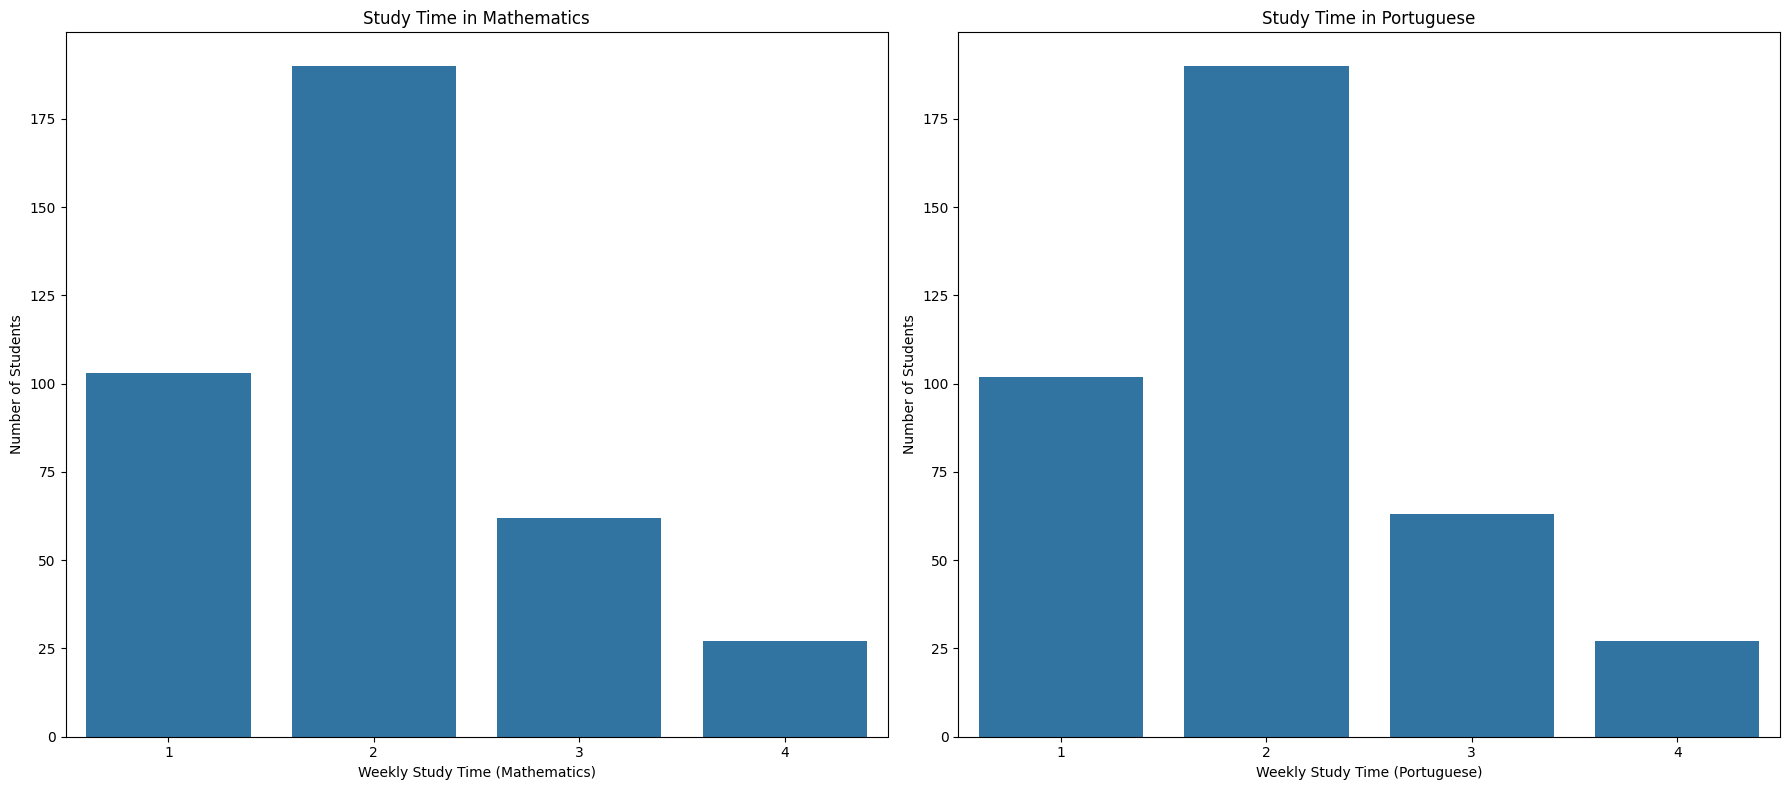

In [140]:
# Countplot of 'studytime_mat'and 'studytime_por'

plt.figure(figsize=(18, 8))

plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
sns.countplot(x="studytime_mat", data=merged)
plt.title('Study Time in Mathematics')
plt.xlabel('Weekly Study Time (Mathematics)')
plt.ylabel('Number of Students')

plt.subplot(1, 2, 2) # plotting the 'studytime_por' on the second column
sns.countplot(x="studytime_por", data=merged)
plt.title('Study Time in Portuguese')
plt.xlabel('Weekly Study Time (Portuguese)')
plt.ylabel('Number of Students')

plt.tight_layout() # This adjusts subplot parameters for a tight layout
plt.show()

### Distribution of Study Time Interpretation

The displayed countplots show the distribution of weekly study time spent by students attending the classes of Mathematics and Portuguese. While the x-axis displays the type of weekly study time in categories (1: <2 hours, 2: 2–5 hours, 3: 5–10 hours, 4: >10 hours), the y-axis shows the number of students who study during this period. The main observations are the following:

- Main Study Time Categories: In both cases, most students are located in categories 2 (2–5 hours) and 1 (<2 hours), meaning that the majority of students spend only a moderate or relatively low time on weekly studies.
- Less Frequent Higher Categories: There are fewer students who study 5 hours or more than 10 hours a week.
- Similarity of Distributions: The distributions for both courses appear to be rather similar to each other which means that no significant differences exist between the time students spend on their studies depending on the course.

### Recommendations for Stakeholders:

- Encouraging Students' Dedication: As the majority of students devote up to five hours to their weekly study time, it is necessary to encourage longer study periods for some students especially in difficult classes. It can include holding sessions on effective study skills and discussing how study time affects their grades.
- Elimination of Barriers: For the few students who study very little, it is essential to discuss why they devote little time to studying because their time can be limited by outside factors.
- Providing Assistance: Fewer students who study more (categories 3 and 4) may benefit from being given additional assistance or mentorship.
- Allocation of Resources: Education institutions may need to allocate additional educational resources (quiet areas for studying, tutorials, etc.) for students whose study times vary significantly.

#### **Previous Failures Distribution**
These help identify predictors of academic risk

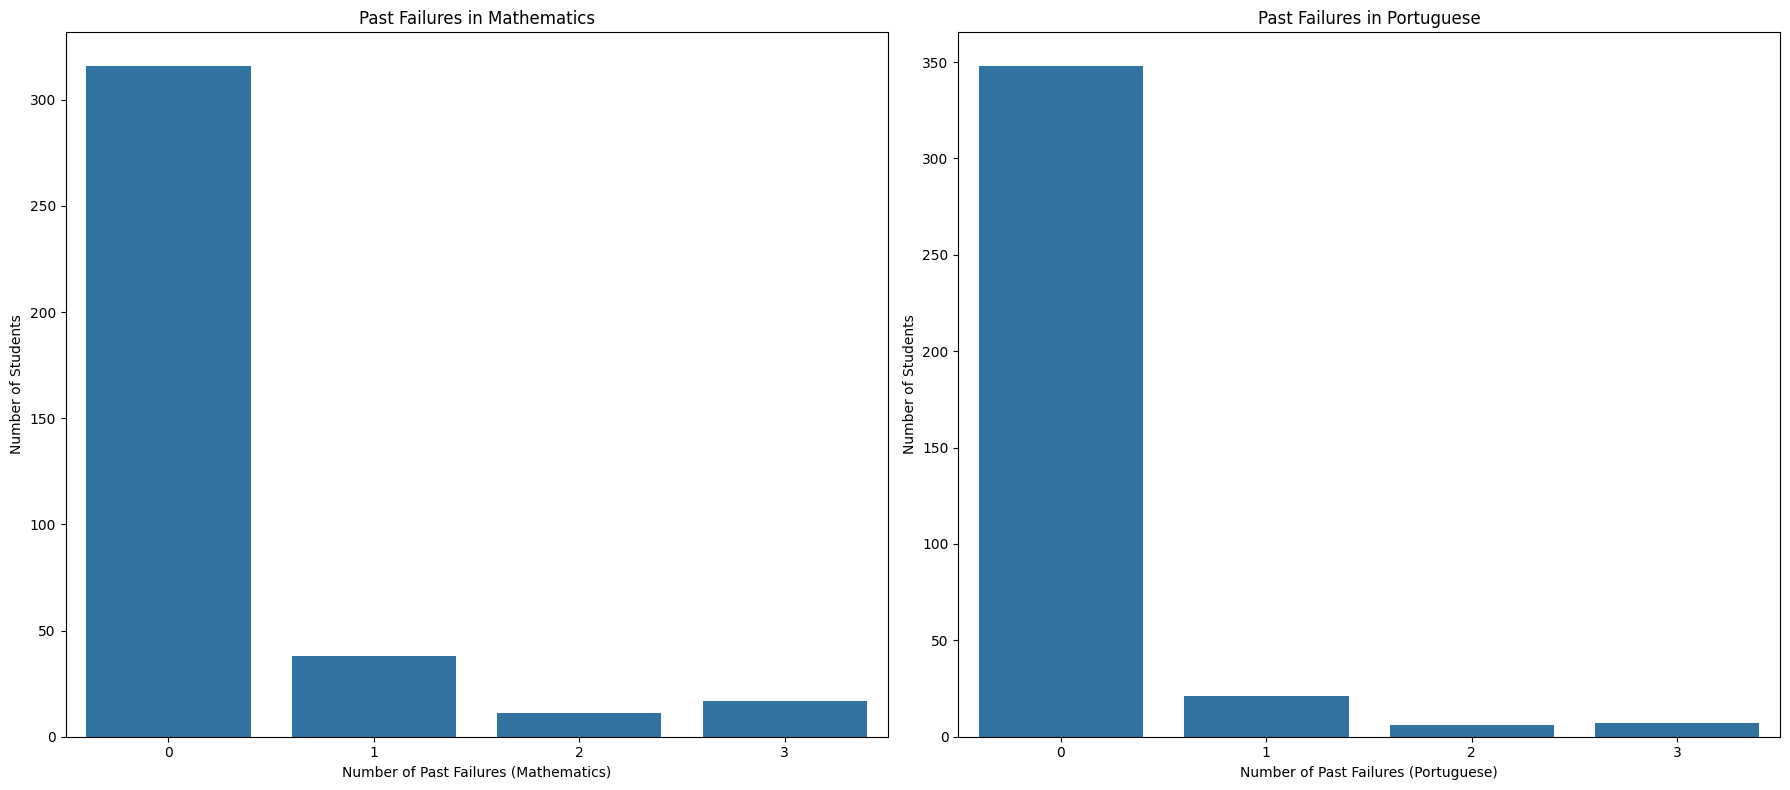

In [141]:
# Countplot of 'failures_mat' and 'failures_por'

plt.figure(figsize=(18, 8))

plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
sns.countplot(x="failures_mat", data=merged)
plt.title('Past Failures in Mathematics')
plt.xlabel('Number of Past Failures (Mathematics)')
plt.ylabel('Number of Students')

plt.subplot(1, 2, 2) # plotting the 'failures_por' on the second column
sns.countplot(x="failures_por", data=merged)
plt.title('Past Failures in Portuguese')
plt.xlabel('Number of Past Failures (Portuguese)')
plt.ylabel('Number of Students')

plt.tight_layout() # This adjusts subplot parameters for a tight layout
plt.show()

### Interpretation of Distribution of Past Failures

The above figures represent the distribution of past failures in the case of mathematics and portuguese. From the count plots, it is possible to make the following conclusions:

- High Number with Zero Past Failures: It is clear that there is a very high percentage of students who have no past failure records. This means that there are few cases where there were multiple failures by the student in either of the two subjects.
- Reduced Count with an Increase in Failures: With increasing failure records (one, two and three), there was a sharp reduction in the counts. This is understandable, since the number of those with such failures is relatively smaller.
- '4' Represents 3+ Past Failures: The count plot with respect to '4' refers to students with past failures of three and above. Even though this is a relatively low proportion of students, it is important to understand the significance behind the data in this category.

### Implications for Parties Involved:

- Importance of Early Detection of Risk Groups: The data strongly indicates the need to consider early detection and intervention for those few students with past failures of one or more. It will be easier to prevent future academic failures.
- Need for Personalized Care: Since a relatively smaller proportion of students have multiple failures, intervention programs can be specifically designed for each of these individual students.
- Resource Utilization: The allocation of resources can be done considering the fact that only a few students are at risk of repeating the classes. The majority of the students score well.
- Difference between Subjects: Comparing failures in mathematics with that in portuguese (failures_mat vs failures_por) will help determine whether there is any difference between the two subjects.

#### **Parental Education Distribution**

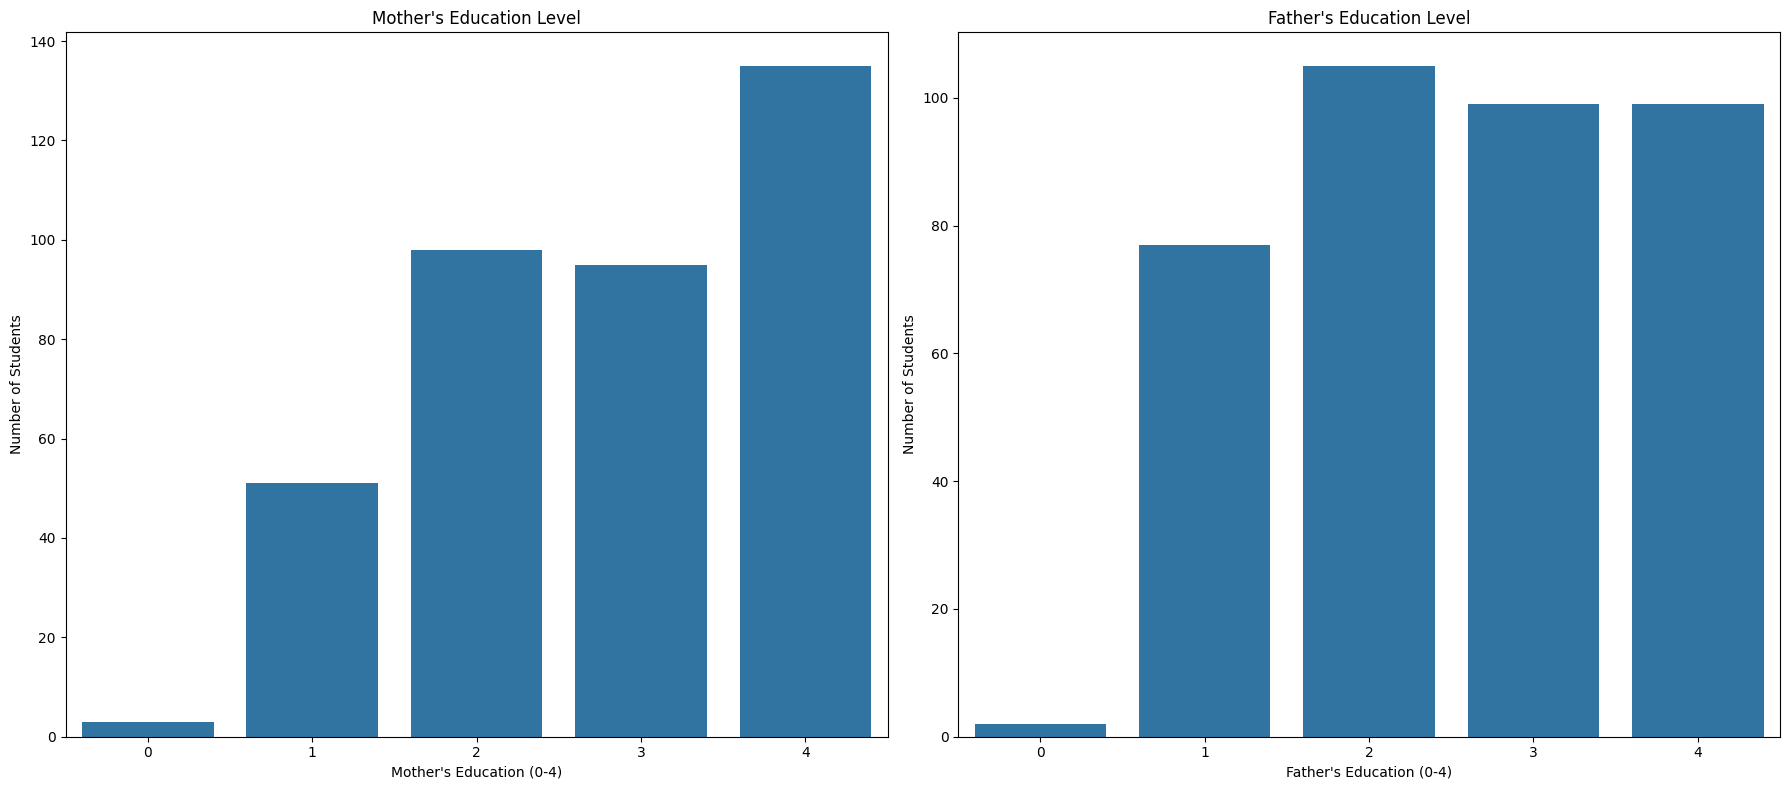

In [142]:
# Parental education distribution plot

plt.figure(figsize=(18, 8))

plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
sns.countplot(x="Medu", data=merged)
plt.title('Mother\'s Education Level')
plt.xlabel('Mother\'s Education (0-4)')
plt.ylabel('Number of Students')

plt.subplot(1, 2, 2) # plotting the 'Fedu' on the second column
sns.countplot(x="Fedu", data=merged)
plt.title('Father\'s Education Level')
plt.xlabel('Father\'s Education (0-4)')
plt.ylabel('Number of Students')

plt.tight_layout() # This adjusts subplot parameters for a tight layout
plt.show()

### Distribution of Parental Education Levels

As seen in the count plots below, the graphs show the distribution of educational levels of parental education for both mothers (Medu) and fathers (Fedu). Education level values range from 0 (none) to 4 (higher education). The observations are as follows:

- Mother's Education Level (Medu): The distribution of the mother's educational level exhibits high frequencies in the categories 2 (5th–9th grade) and 4 (higher education). Furthermore, the category 3 (secondary education) shows a reasonable frequency. Meanwhile, category 0 (none) and 1 (4th grade) demonstrate lower frequency levels.
- Father's Education Level (Fedu): Similarly to the above case, the father's educational level distribution also displays high levels of frequencies in the two groups, namely, 2 (lower education) and 4 (higher education). A more exact analysis would help determine peaks and troughs in each category; however, it is clear what the distribution looks like.
- Overall Trend: Generally, there is a clear existence of parents possessing higher education (4) both for the mothers and the fathers. Thus, a substantial percentage of students comes from families with high-level educated parents. Meanwhile, many cases exist, in which students come from less educated families.

### Stakeholder Insights:

- Relationship with Student Success: As a rule, parental education level proves to be an efficient predictor of home learning conditions, as well as available help for the students from their parents. Thus, an analysis can be performed to see whether Medu/Fedu are related to the student's performance (risk variable).
- Additional Support Programs: If the parental education level is quite low, schools might develop some additional activities, like providing parental courses on helping with homework and other academic issues for children who lack parental educational guidance.
- Communication Strategies: Knowing what kind of parental education the student has allows developing communication strategies accordingly. Schools might organize events with simplified instructions or several languages to reach all audiences.
- Educational Disparity: In the case where parental education level has a close relationship with higher student risks, these statistics can be used to reduce educational disparity.

## Bivariate Analysis

#### **Study Time vs Risk**

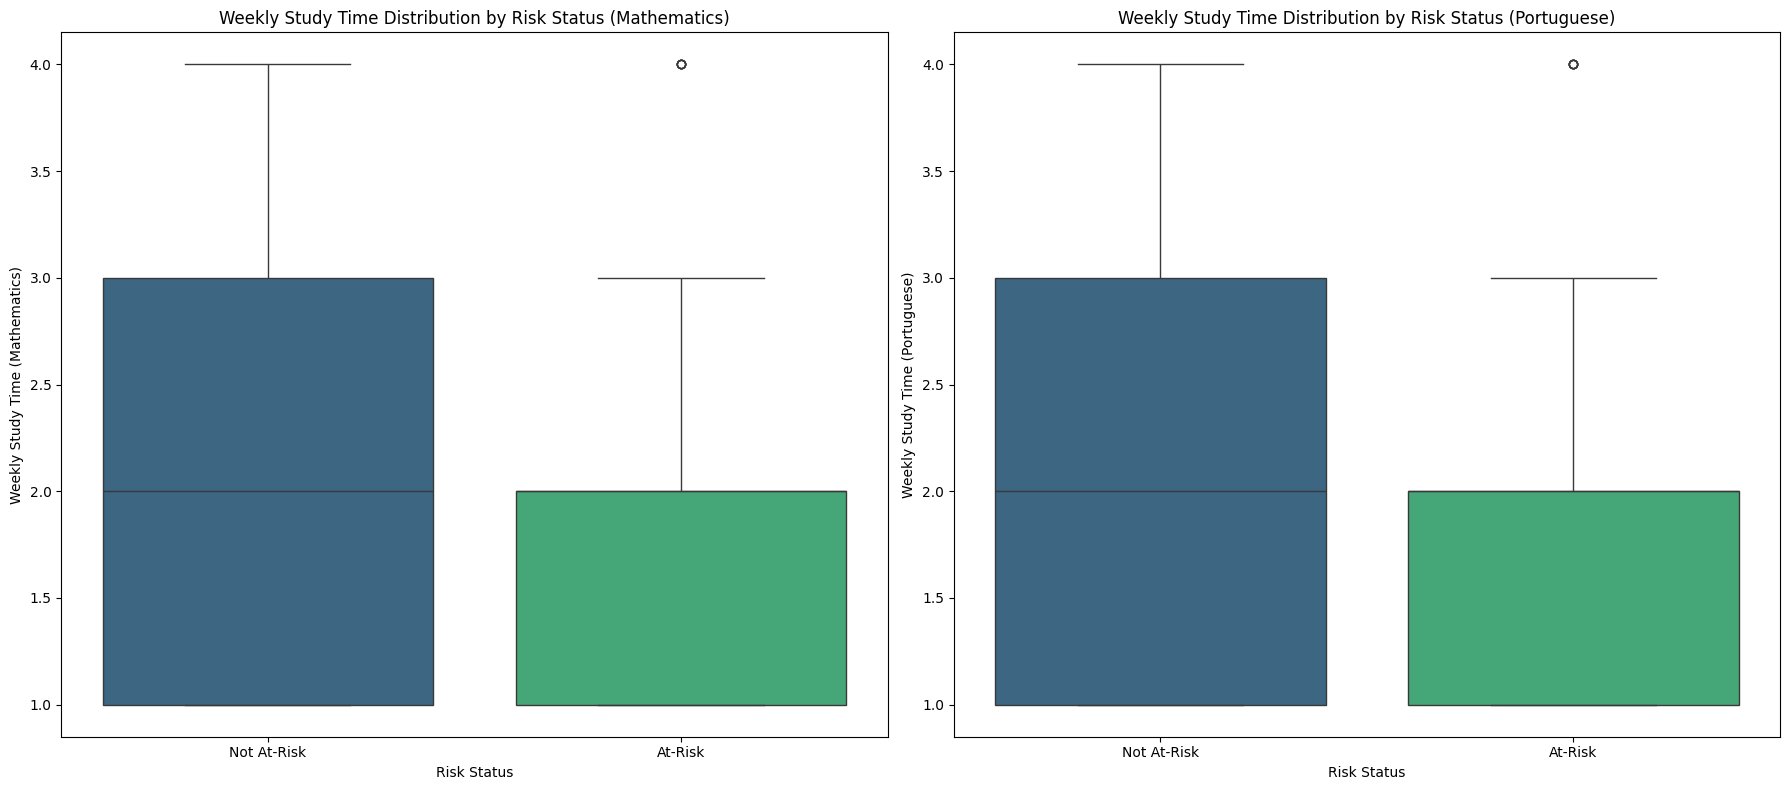

In [143]:
# study time vs risk analysis

plt.figure(figsize=(18, 8))

plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
sns.boxplot(x='risk', y='studytime_mat', data=merged, palette='viridis')
plt.title('Weekly Study Time Distribution by Risk Status (Mathematics)')
plt.xlabel('Risk Status')
plt.ylabel('Weekly Study Time (Mathematics)')
plt.xticks([0, 1], ['Not At-Risk', 'At-Risk'])

plt.subplot(1, 2, 2) # plotting the 'studytime_por' on the second column
sns.boxplot(x='risk', y='studytime_por', data=merged, palette='viridis')
plt.title('Weekly Study Time Distribution by Risk Status (Portuguese)')
plt.xlabel('Risk Status')
plt.ylabel('Weekly Study Time (Portuguese)')
plt.xticks([0, 1], ['Not At-Risk', 'At-Risk'])

plt.tight_layout()
plt.show()

### Interpretation of Study Time Relative to Risk (Boxplot)

The boxplots represent the distribution of weekly study time of the students taking courses in Mathematics (studytime_mat) and Portuguese (studytime_por), based on their academic risk status (0 = Not At-Risk, 1 = At-Risk). The x-axis represents risk status, and the y-axis represents weekly study time in terms of categories ranging from 1 to 4, with 1 indicating less than 2 hours, and 4 being above 10 hours.

### Observations from the Plot:

- Lower Study Time Among At-Risk Students: In relation to academic risk status, there appears to be lower study time among students that are classified as At-Risk (1). This applies to both subjects, meaning that the boxes representing At-Risk students are clustered towards lower study-time categories.
- Higher Study Time Among Not At-Risk Students: On the other hand, not at-risk students have higher study times as their boxes appear to cluster towards high study-time categories.
- Consistent Pattern Across the Two Subjects: There does not seem to be much of a difference in terms of this pattern for both mathematics and Portuguese, which implies that the study behavior leading to higher risk is similar regardless of subject.
- Study-Time Distribution: Both the boxes for At-Risk and Not At-Risk students have various points that indicate dispersion across different study-time categories, yet the distribution indicates that high engagement in studying means lower academic risk, while less time spent on studying leads to higher risk.

### Implication for Stakeholders:

- Study Time Predicts Academic Risk: Weekly study time plays a key role in determining academic risk status. It has been noted that students who spend less time studying are more likely to be At-Risk.
- Increasing Study Time Interventions: Educational institutions should ensure that At-Risk students spend sufficient time studying. Strategies such as workshops on studying techniques, forming study groups per subject matter, among others, would prove effective in increasing study time.
- Identifying Barriers to Study Habits: Students that constantly report low weekly study times should have their issues analyzed so as to understand why they engage in such little time on the subject matter.
- Creating a Studying Environment: Universities could create an atmosphere that is conductive to studying, whereby learning materials are available, suitable quiet zones are offered, and mentorship programs are developed.
- Parents/Guardians' Education: Information regarding the importance of spending time studying could be communicated to parents/guardians so that they learn strategies that enable students to spend more time on the subjects at home.
- Early Warning Systems: The use of study time indicators in early warning systems could help in identifying At-Risk students that spend less time on studying.

#### **Failures vs Risk**

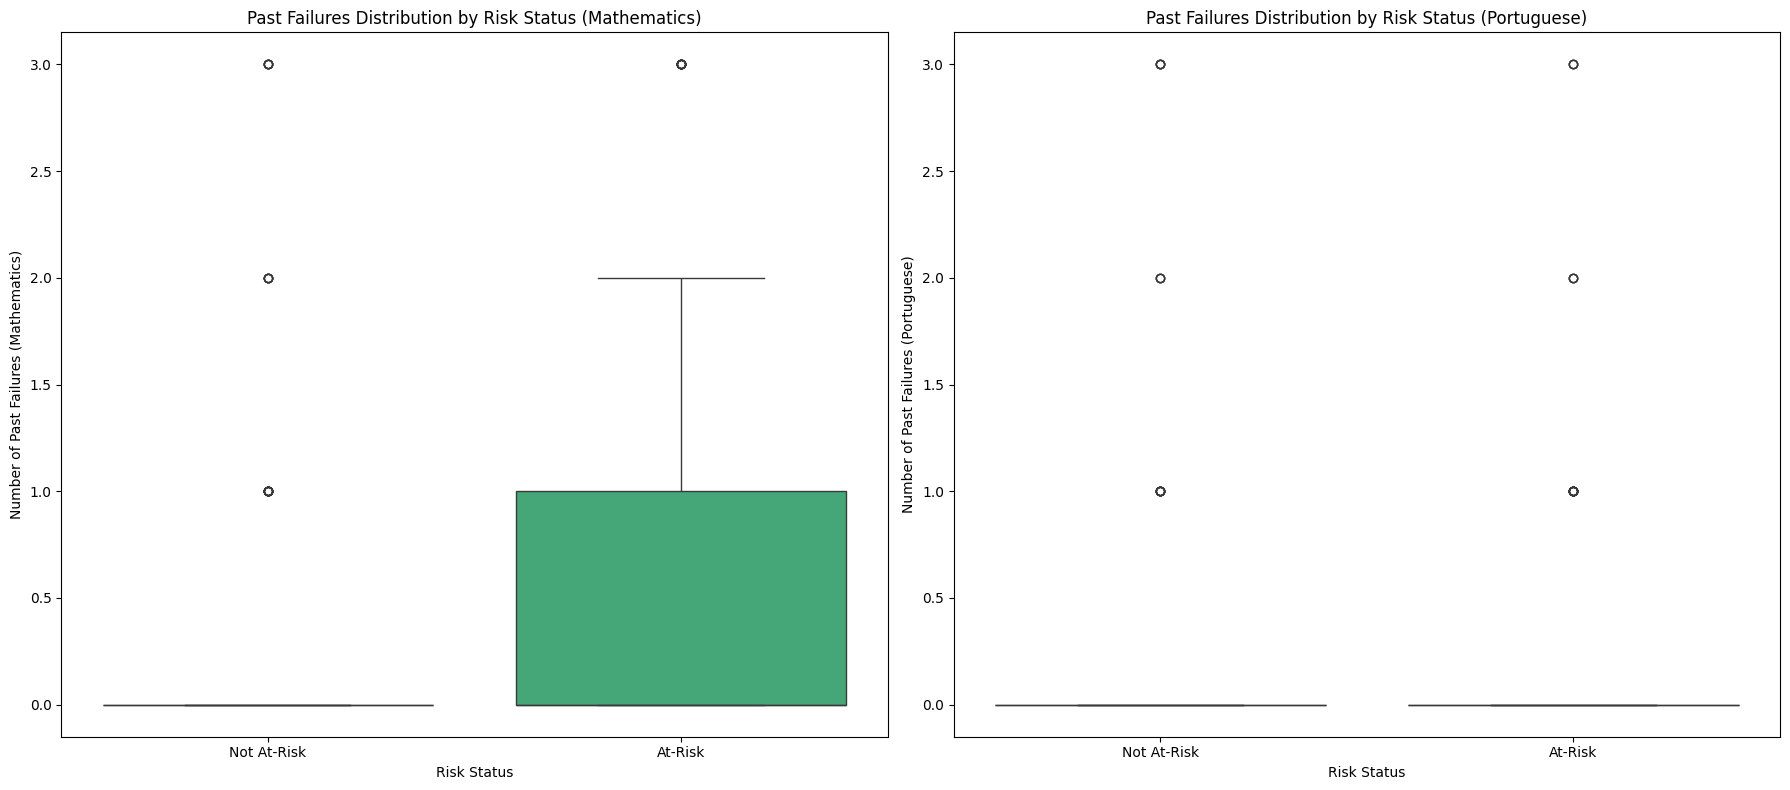

In [144]:
# Plot of Failures vs Risk

plt.figure(figsize=(18, 8))

plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
sns.boxplot(x='risk', y='failures_mat', data=merged, palette='viridis')
plt.title('Past Failures Distribution by Risk Status (Mathematics)')
plt.xlabel('Risk Status')
plt.ylabel('Number of Past Failures (Mathematics)')
plt.xticks([0, 1], ['Not At-Risk', 'At-Risk'])

plt.subplot(1, 2, 2) # plotting the 'failures_por' on the second column
sns.boxplot(x='risk', y='failures_por', data=merged, palette='viridis')
plt.title('Past Failures Distribution by Risk Status (Portuguese)')
plt.xlabel('Risk Status')
plt.ylabel('Number of Past Failures (Portuguese)')
plt.xticks([0, 1], ['Not At-Risk', 'At-Risk'])

plt.tight_layout()
plt.show()

### Failures vs. Risk (Boxplots): Interpretations

The box plots represent the distribution of past academic failures in the subjects Mathematics and Portuguese among At-Risk and Not At-Risk students. In this case, the horizontal axis represents student risk status (At-Risk/Not At-Risk), whereas the vertical axis reflects past academic failures. The box plot displays the information about medians, interquartile ranges, and potential outliers concerning past failures in each group.

### Key Observations:

- Distinction: There is a clear distinction between the two groups of students with respect to their number of past failures, where the Not At-Risk (0) group is characterized by zero past failures as median, while most of the students do not have academic failures.
- Past failures as a predictor: The students in the At-Risk group (1) have significantly higher medians of past failures and shifted distribution compared to the other category, which implies that the history of academic failures in the past is an important factor when determining whether or not a student is At-Risk.
- Spread of the At-Risk group: There is generally a larger spread of failures in terms of interquartile ranges in the At-Risk category, meaning that it includes the largest numbers of past failures and is characterized by the highest variability of this variable compared to the other group.
- Subjects: The results were obtained both for the subjects of mathematics (failures_mat) and Portuguese (failures_por).

### Insights for Stakeholders

- Strong Predictor: Past academic failures is a powerful predictor in the context of risk and requires close attention from decision makers.
- Interventions: Any history of past failures, even one single case, requires intervention as a preventive measure against developing academic risk and needs to be acted upon right away.
- Individualized Support Plan: For cases where there are past academic failures, it is necessary to develop a personalized support plan tailored to individual needs of a student to identify the reasons for the failure and provide adequate help.
- Early Warning System: It is recommended to create an early warning system for academic failures, such that the very first academic failure serves as a reason to intervene.
- Allocation of Resources: Educational resources should be allocated to the target group of students in order to help prevent further failures and reduce risk.

#### **Absences vs Risk**

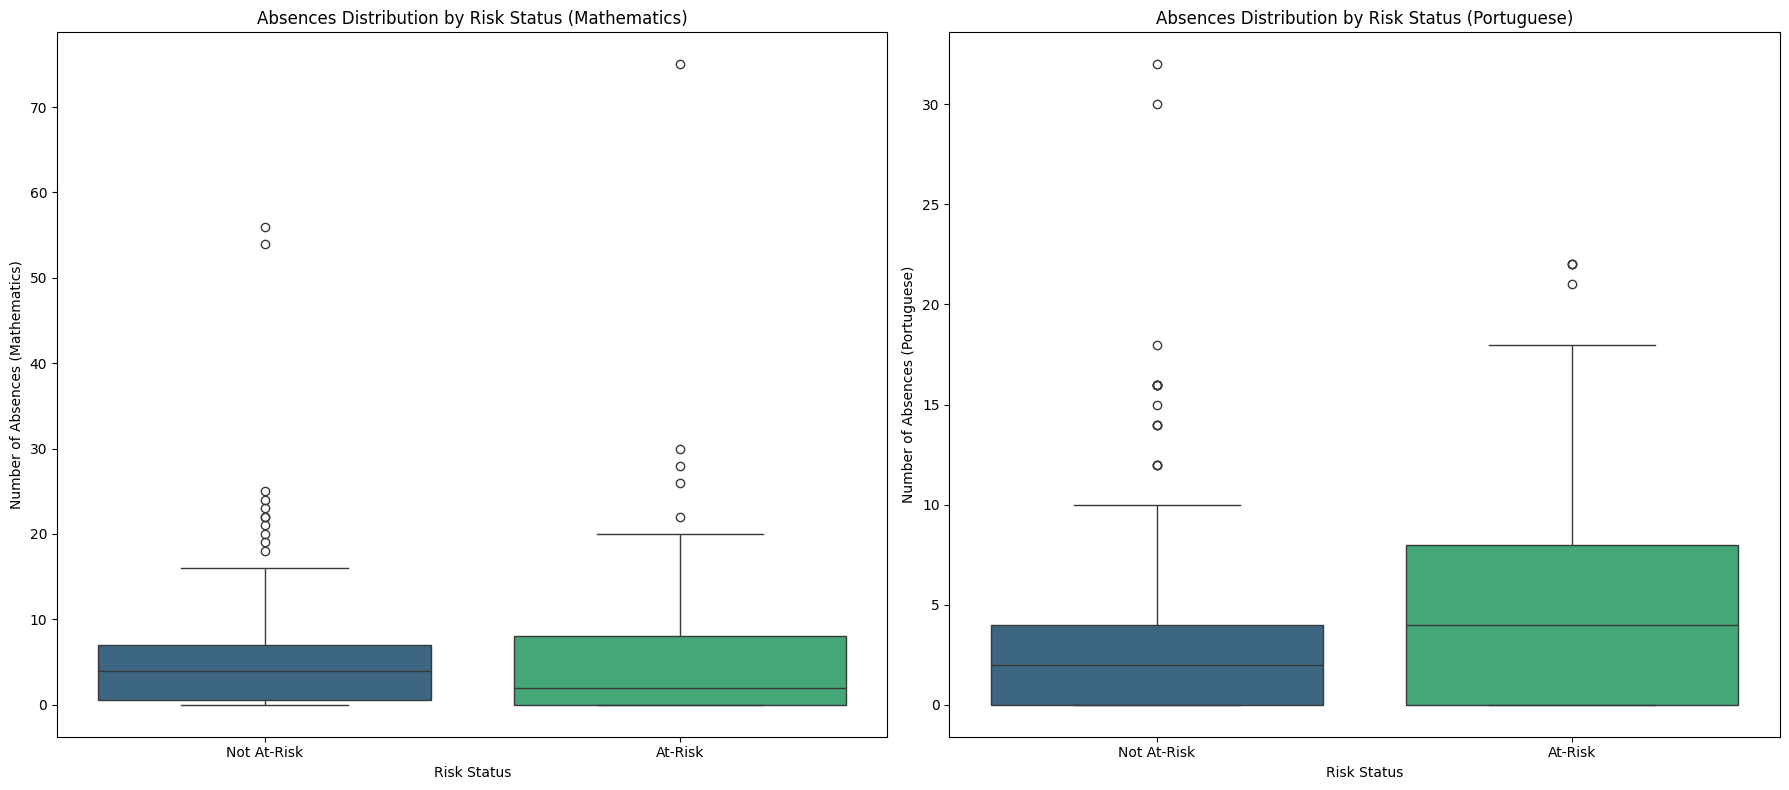

In [145]:
# Plot of Absences vs Risk

plt.figure(figsize=(18, 8))

plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
sns.boxplot(x='risk', y='absences_mat', data=merged, palette='viridis')
plt.title('Absences Distribution by Risk Status (Mathematics)')
plt.xlabel('Risk Status')
plt.ylabel('Number of Absences (Mathematics)')
plt.xticks([0, 1], ['Not At-Risk', 'At-Risk'])

plt.subplot(1, 2, 2) # plotting the 'absences_por' on the second column
sns.boxplot(x='risk', y='absences_por', data=merged, palette='viridis')
plt.title('Absences Distribution by Risk Status (Portuguese)')
plt.xlabel('Risk Status')
plt.ylabel('Number of Absences (Portuguese)')
plt.xticks([0, 1], ['Not At-Risk', 'At-Risk'])

plt.tight_layout()
plt.show()

### Interpretation of Absences Relative to Risk (Boxplots)

The above boxplots provide information on the number of absences of Mathematics and Portuguese students who are at different levels of academic risk (0 = Not At-Risk; 1 = At-Risk). Here, the horizontal axis represents the level of risk, and the vertical axis represents the number of absences. The boxes contain the IQR, median, and outliers where applicable.

### Key Points:

- High Number of Absences Among Students 'At-Risk': For both subjects, the students labeled as 'At-Risk' (1) have higher medians for their number of absences than the students labeled 'Not At-Risk' (0). Their boxplot is higher on average.
- Higher Variance in 'At-Risk' Students: The boxplots of students 'At-Risk' (1) have a higher IQR than their peers, indicating higher variance in absences within this group. Therefore, the presence of moderately high absence rates can be observed for some, and extremely high rates for others.
- Presence of Outliers: Both categories have outliers; however, the category of 'At-Risk' students (1) appears to have many more outliers whose values tend to be higher.
- Similar Results Across Subjects: The link between higher number of absences and higher risk status is consistent across Mathematics and Portuguese.

### Recommendations to Stakeholders:

- Importance of Monitoring Attendance Rates: Absence rates appear to be reliable indicators of academic risk status. Monitoring attendance should become part of any early warning system for poor student performance.
- Identification and Intervention of Root Causes: Students that display consistently high absence rates must be examined for possible causes of their situation, which could range from health problems to personal/family conflicts and lack of engagement. Finding out the reasons would make it easier to intervene and address them.
- Provide Special Attention: It is important to provide special attention to students with high rates of absenteeism, especially for those 'At-Risk'. Such interventions could involve counseling, programs designed to improve attendance, academic coaching, etc.
- Raising Awareness about the Importance of School Attendance: Educational programs should emphasize the significance of regular attendance to all students and their parents/guardians.
- Review of Attendance Policies: Such policies need to be reviewed to ensure they promote attendance rather than discourage it with harsh penalties.

### Correlation Heatmap

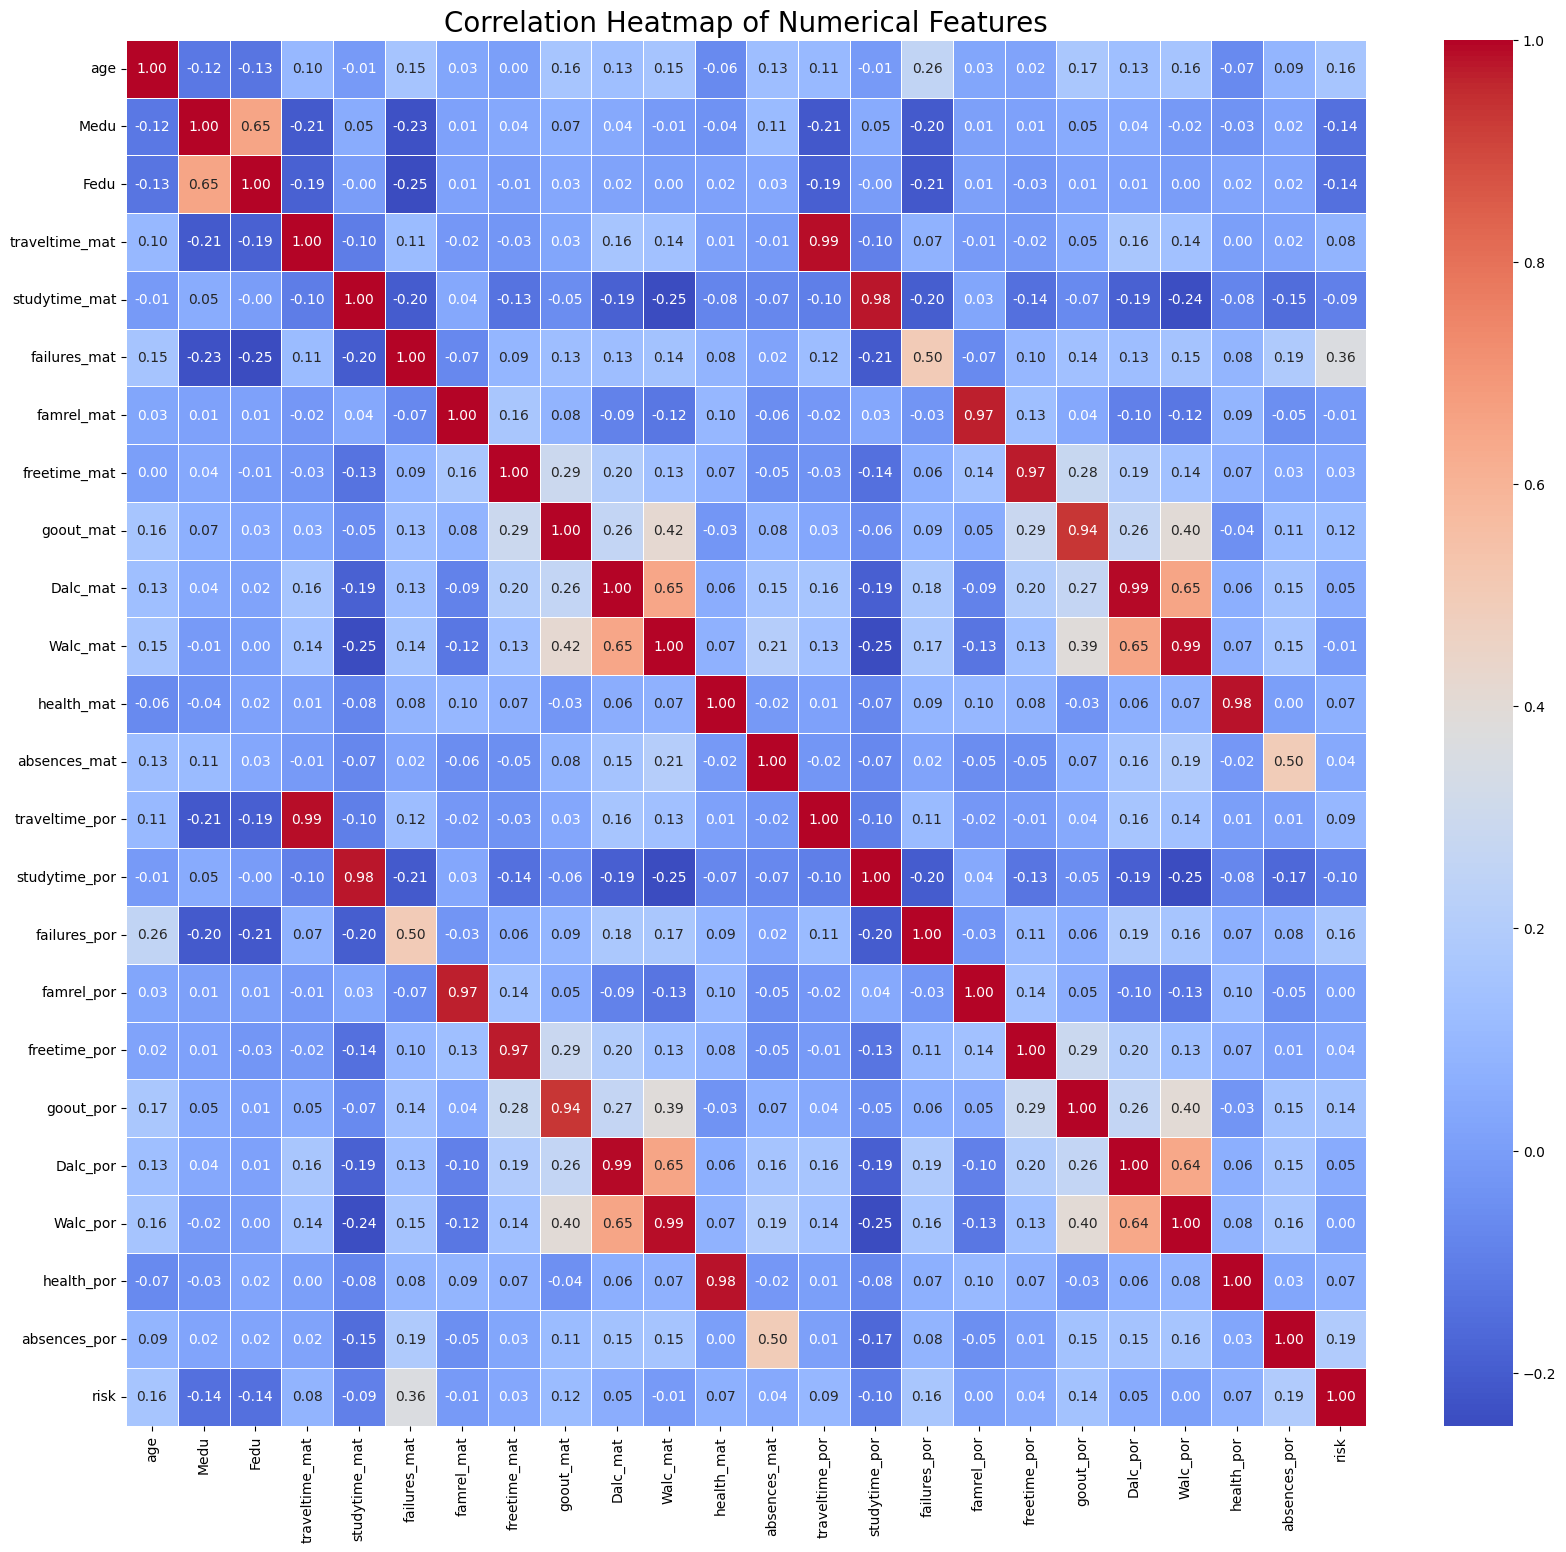

In [146]:
# Correlation Matrix for numerical variables

# Select only numerical columns for correlation matrix
numerical_cols = merged.select_dtypes(include=np.number).columns
corr_matrix = merged[numerical_cols].corr()

# Plotting the heatmap
plt.figure(figsize=(20, 18))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Heatmap of Numerical Features', fontsize=20)
plt.show()

### Analysis of the Correlation Heatmap

The correlation heatmap is a chart that presents the coefficients of correlation between each two numeric variables present in the dataset. The intensity of the color (cool /warm) represents the degree of correlation (low/strong), while the direction of the relation is indicated by its positive or negative value.

### Main Findings:

- Target Variable (Risk) Correlations:
  - Strong Positive Correlation with failures: failures_mat and failures_por demonstrate a strong positive correlation with the target risk variable. This means that there is a strong link between the number of failures a student has had and their belonging to the category 'At-Risk'.
  - Moderate Positive Correlation with absences: absences_mat and absences_por are positively correlated with the variable under analysis. This indicates that more absences are linked to a higher likelihood of 'At-Risk' classification.
  - Negative Correlation with Parental Education: Medu and Fedu are negatively correlated with risk. Higher levels of parental education reduce the chance that students are 'At-Risk'.
  - Negative Correlation with studytime: studytime_mat and studytime_por variables demonstrate negative correlations with the target risk variable, meaning that those who spend more time on studying tend to belong to the category 'Not At-Risk'.
  - Weak to Moderate Positive Correlation with Dalc and Walc: alcohol consumption both at workdays (Dalc) and on weekends (Walc) shows a weak to moderate positive correlation with the risk variable.

- Multicollinearity Issues (Inter-Feature Correlation):
  - Strong Correlation Between Subject-Specific Variables: variables from Mathematics and Portuguese, that measure the same metric (absences_mat/absences_por; studytime_mat/studytime_por; failures_mat/failures_por; Dalc_mat/Dalc_por; Walc_mat/Walc_por), show strong positive correlation with each other because these metrics reflect the data on the same students but on two courses.
  - Age and Failures: age is positively correlated with failures_mat and failures_por.

### Stakeholders' Insights:

- Major Risk Indicators: the variables with the strongest positive correlation with the risk variable should receive top priority in early prevention actions. These are historical failures and absences.
- Sociocultural Factors: parental education level (Medu/Fedu) plays a big role in making a prediction, as the risk category includes many students from poorly-educated families.
- Lifestyles and Habits: studytime and alcohol consumption variables positively correlate with the target variable. Encouraging regular study and addressing issues related to alcohol consumption can be helpful for prevention.
- Multi-Faceted Problem of 'At-Risk': high levels of intercorrelation between subject-specific variables show that a single student can be 'At-Risk' not because of a specific subject, but due to multiple factors affecting his or her academic performance.
- Feature Engineering for Predictive Analysis: a strong positive correlation between subject-specific variables creates the risk of multicollinearity, which should be taken into account in future work with the dataset.

## Feature Engineering

#### **1. Featuring Engineering for Parental Education Average**

In [147]:
# Creating out "Parental Education Average" from the dataset

merged["parent_edu_avg"] = (merged["Medu"] + merged["Fedu"]) / 2

This new parental education average feature aims to provide a combined indicator of parental educational background.

In [148]:
merged["parent_edu_avg"].head(10)

,parent_edu_avg
0,4.0
1,1.0
2,1.0
3,3.0
4,3.0
5,3.5
6,2.0
7,4.0
8,2.5
9,3.5


In [149]:
merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 382 entries, 0 to 381
Data columns (total 49 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   school          382 non-null    object 
 1   sex             382 non-null    object 
 2   age             382 non-null    int64  
 3   address         382 non-null    object 
 4   famsize         382 non-null    object 
 5   Pstatus         382 non-null    object 
 6   Medu            382 non-null    int64  
 7   Fedu            382 non-null    int64  
 8   Mjob            382 non-null    object 
 9   Fjob            382 non-null    object 
 10  reason          382 non-null    object 
 11  guardian_mat    382 non-null    object 
 12  traveltime_mat  382 non-null    int64  
 13  studytime_mat   382 non-null    int64  
 14  failures_mat    382 non-null    int64  
 15  schoolsup_mat   382 non-null    object 
 16  famsup_mat      382 non-null    object 
 17  paid_mat        382 non-null    obj

#### **2. Featuring Engineering for Lifestyle Indicator**

In [150]:
# Creating out "Lifestyle Indicator" from the dataset

merged["lifestyle_score"] = merged["goout_mat"] + merged["goout_por"]

This new lifestyle indicator feature aims to create a combined indicator of a student's social activity or 'going' out habits across both subjects.

In [151]:
merged["lifestyle_score"].head(10)

,lifestyle_score
0,8
1,6
2,4
3,4
4,4
5,4
6,8
7,8
8,4
9,2


In [152]:
merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 382 entries, 0 to 381
Data columns (total 50 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   school           382 non-null    object 
 1   sex              382 non-null    object 
 2   age              382 non-null    int64  
 3   address          382 non-null    object 
 4   famsize          382 non-null    object 
 5   Pstatus          382 non-null    object 
 6   Medu             382 non-null    int64  
 7   Fedu             382 non-null    int64  
 8   Mjob             382 non-null    object 
 9   Fjob             382 non-null    object 
 10  reason           382 non-null    object 
 11  guardian_mat     382 non-null    object 
 12  traveltime_mat   382 non-null    int64  
 13  studytime_mat    382 non-null    int64  
 14  failures_mat     382 non-null    int64  
 15  schoolsup_mat    382 non-null    object 
 16  famsup_mat       382 non-null    object 
 17  paid_mat        



---



In [153]:
merged.head(10)

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel_por,freetime_por,goout_por,Dalc_por,Walc_por,health_por,absences_por,risk,parent_edu_avg,lifestyle_score
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,4,1,4.0,8
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,2,1,1.0,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,6,0,1.0,4
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,0,0,3.0,4
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,0,0,3.0,4
5,GP,M,16,U,LE3,T,4,3,services,other,...,5,4,2,1,2,5,6,0,3.5,4
6,GP,M,16,U,LE3,T,2,2,other,other,...,4,4,4,1,1,3,0,0,2.0,8
7,GP,F,17,U,GT3,A,4,4,other,teacher,...,4,1,4,1,1,1,2,1,4.0,8
8,GP,M,15,U,LE3,A,3,2,services,other,...,4,2,2,1,1,1,0,0,2.5,4
9,GP,M,15,U,GT3,T,3,4,other,other,...,5,5,1,1,1,5,0,0,3.5,2


In [214]:
merged.shape

(382, 50)

## Model Development

### Encode Categorical Variables

In [154]:
from sklearn.preprocessing import LabelEncoder
import joblib

encoders = {}

for column in merged.columns:
    if merged[column].dtype == "object":
        le = LabelEncoder()
        merged[column] = le.fit_transform(merged[column])
        encoders[column] = le

The `for` loop iterates through every column in the aggregated dataframe in order to identify and convert object data types into numerical data types. This is considered a standard process before modeling using machine learning algorithms, since most algorithms require numeric inputs.

In [171]:
# Save the Encoded variables for future deployment

joblib.dump(encoders, "label_encoders.pkl")

['label_encoders.pkl']

In [170]:
# Confirm encoded variables

encoders = joblib.load("label_encoders.pkl")
print(encoders.keys())

dict_keys(['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob', 'reason', 'guardian_mat', 'schoolsup_mat', 'famsup_mat', 'paid_mat', 'activities_mat', 'nursery', 'higher_mat', 'internet', 'romantic_mat', 'guardian_por', 'schoolsup_por', 'famsup_por', 'paid_por', 'activities_por', 'higher_por', 'romantic_por'])


In [155]:
merged.head(10)

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel_por,freetime_por,goout_por,Dalc_por,Walc_por,health_por,absences_por,risk,parent_edu_avg,lifestyle_score
0,0,0,18,1,0,0,4,4,0,4,...,4,3,4,1,1,3,4,1,4.0,8
1,0,0,17,1,0,1,1,1,0,2,...,5,3,3,1,1,3,2,1,1.0,6
2,0,0,15,1,1,1,1,1,0,2,...,4,3,2,2,3,3,6,0,1.0,4
3,0,0,15,1,0,1,4,2,1,3,...,3,2,2,1,1,5,0,0,3.0,4
4,0,0,16,1,0,1,3,3,2,2,...,4,3,2,1,2,5,0,0,3.0,4
5,0,1,16,1,1,1,4,3,3,2,...,5,4,2,1,2,5,6,0,3.5,4
6,0,1,16,1,1,1,2,2,2,2,...,4,4,4,1,1,3,0,0,2.0,8
7,0,0,17,1,0,0,4,4,2,4,...,4,1,4,1,1,1,2,1,4.0,8
8,0,1,15,1,1,0,3,2,3,2,...,4,2,2,1,1,1,0,0,2.5,4
9,0,1,15,1,0,1,3,4,2,2,...,5,5,1,1,1,5,0,0,3.5,2


**Comment**: We can see that the objects variables such as `school` and `sex` have been transformed into numerical values. This is called 'Label Encoding'.

### Define Features and Target

In [158]:
X = merged.drop("risk", axis=1) # drop the target variable 'risk' from the dataframe

y = merged["risk"]

In [159]:
X.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,romantic_por,famrel_por,freetime_por,goout_por,Dalc_por,Walc_por,health_por,absences_por,parent_edu_avg,lifestyle_score
0,0,0,18,1,0,0,4,4,0,4,...,0,4,3,4,1,1,3,4,4.0,8
1,0,0,17,1,0,1,1,1,0,2,...,0,5,3,3,1,1,3,2,1.0,6
2,0,0,15,1,1,1,1,1,0,2,...,0,4,3,2,2,3,3,6,1.0,4
3,0,0,15,1,0,1,4,2,1,3,...,1,3,2,2,1,1,5,0,3.0,4
4,0,0,16,1,0,1,3,3,2,2,...,0,4,3,2,1,2,5,0,3.0,4


In [160]:
y.head()

,risk
0,1
1,1
2,0
3,0
4,0


### Split the Data into Training and Testing Set

In [161]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
                                                    random_state=42)


In [162]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (305, 49)
X_test shape: (77, 49)


### Model Training and Evaluation

In [185]:
# Machine learning models
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, recall_score, f1_score, precision_score, classification_report, confusion_matrix, roc_auc_score

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

# Library for saving trained model
import joblib

In [193]:
# Define models to train and evaluate

# Add class_weight balance
models = {
    "Logistic Regression": LogisticRegression(max_iter=2000, class_weight="balanced"),
    "Decision Tree": DecisionTreeClassifier(class_weight="balanced", random_state=42),
    "Random Forest": RandomForestClassifier(class_weight="balanced", random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "Support Vector Machine": SVC(probability=True, class_weight="balanced"),
    "K-Nearest Neighbors": KNeighborsClassifier()
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred, pos_label=1)
    precision = precision_score(y_test, y_pred, pos_label=1)
    f1 = f1_score(y_test, y_pred, pos_label=1)
    auc = roc_auc_score(y_test, y_prob)

    results.append([name, acc, precision, recall, f1, auc])

# Model Comparison Table
results_df = pd.DataFrame(
    results,
    columns=["Model", "Accuracy", "Precision", "Recall", "F1 Score", "ROC_AUC"]
)

# Print the Table sorted by 'Recall'
results_df.sort_values(by="Recall", ascending=False)

,Model,Accuracy,Precision,Recall,F1 Score,ROC_AUC
1,Decision Tree,0.805195,0.619048,0.65,0.634146,0.754825
0,Logistic Regression,0.688312,0.416667,0.50,0.454545,0.700877
3,Gradient Boosting,0.792208,0.642857,0.45,0.529412,0.716667
4,Support Vector Machine,0.766234,0.571429,0.40,0.470588,0.691228
2,Random Forest,0.779221,0.800000,0.20,0.320000,0.815351
5,K-Nearest Neighbors,0.727273,0.333333,0.05,0.086957,0.623684


### Interpretation and Model Selection

Decision Tree model is considered the optimal model due to its recall value for the risk class, which reached `0.65`. This signifies better prediction ability when it comes to detecting students who require immediate attention. Since the main objective of the system is not only achieving maximum accuracy but also identifying students who may be at academic risk early on, recall was chosen as the main performance indicator. Moreover, Decision Tree model performed best in terms of overall accuracy at `80.5%`, and F1-Score at `0.634`.

### **Retraining the Best Model (Decision Tree)**

In [200]:
# retraining the best model

best_model = DecisionTreeClassifier(class_weight="balanced", random_state=42)

best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)

# Classification report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.88      0.86      0.87        57
           1       0.62      0.65      0.63        20

    accuracy                           0.81        77
   macro avg       0.75      0.75      0.75        77
weighted avg       0.81      0.81      0.81        77



### **Confusion Matrix**

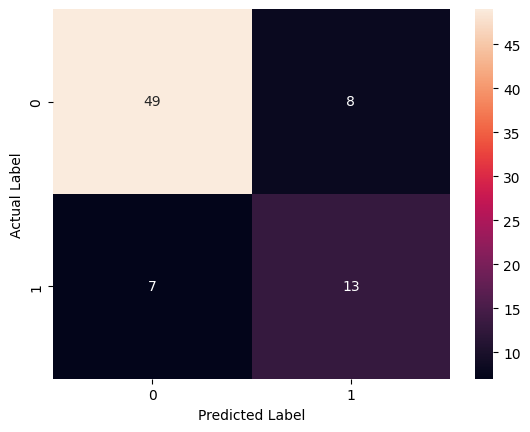

In [205]:
# confusion matrix of the DecisionTreeClassifier
import seaborn as sns

sns.heatmap(
    confusion_matrix(y_test, best_model.predict(X_test)),
    annot=True,
    fmt="d"
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()

### Interpretation

**True Negatives (TN = 49)**

Description: Those students correctly labeled as Not At-Risk.
  
Interpretation: The model correctly classified `49` students as being safe.

**False Positives (FP = 8)**

Description: Students incorrectly classified as At-Risk but are really Not At-Risk.
  
Interpretation: `8` students were falsely tagged.

Reason: These kinds of errors are not problematic when making an early warning because the opposite is more dangerous.

**False Negatives (FN = 7)**

Description: Students classified as Not At-Risk but are really At-Risk.
  
Interpretation: `7` vulnerable students have been ignored.

Importance: False negatives represent the most serious error category.

**True Positives (TP = 13)**

Description: Students labeled as At-Risk by the model.
  
Interpretation: `13` students were identified.

Based on the confusion matrix, it can be said that the model has been able to classify `49` cases as negative and `13` cases as positive. On the other hand, there have been `8` cases where the classifier wrongly predicted that the cases were positive, and there were seven cases which were predicted to be negative but were actually positive. The recall value for the positive class is `65%`, which shows that the classifier was able to identify most students who needed early academic interventions.

## Confusion Matrix of Actual vs Predicted in Percentage

Text(0.5, 23.52222222222222, 'Predicted')

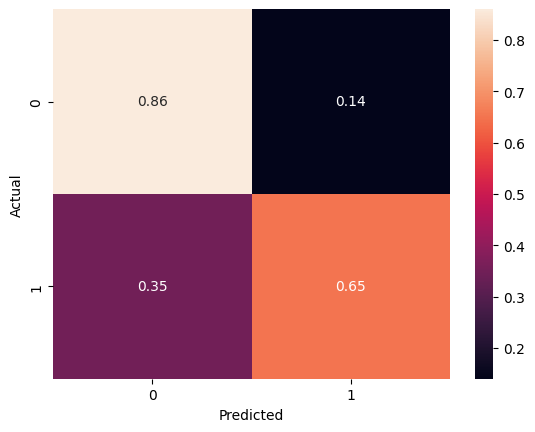

In [206]:
# Confusion matrix of actual vs predicted in %

# initialize the confusion matrix of the prediction
cm = confusion_matrix(y_test, best_model.predict(X_test))

actual = np.sum(cm, axis=1).reshape(-1,1)
cmn = np.round(cm/actual, 2)

sns.heatmap(cmn, annot=True, fmt='.2f', xticklabels=best_model.classes_, yticklabels=best_model.classes_)
plt.ylabel('Actual')
plt.xlabel('Predicted')

### Chart Analysis

As per the normalized confusion matrix, the classifier was able to classify `86` percent of students who were not at risk. At the same time, it was able to detect `65` percent of the students who were at risk. However, the classifier was found to misclassify `14` percent of students who were not at risk as being at risk. Similarly, it was found to misclassify `35` percent of at-risk students as not being at risk.

## Feature Importance - Features Contributing to Student Performance Risk in School

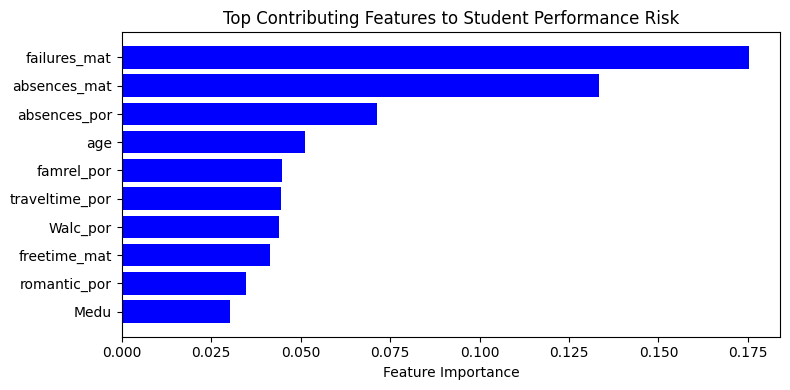

In [217]:
# Get feature importances from the best model
importances = best_model.feature_importances_

# Match to column names
feature_names = X_train.columns
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})

# Sort by importance
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# Select top 10 features
top_10_features = importance_df.head(10)

# Plot top features
plt.figure(figsize=(8, 4))
plt.barh(top_10_features['Feature'], top_10_features['Importance'], color='blue')
plt.xlabel('Feature Importance')
plt.title('Top Contributing Features to Student Performance Risk')
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

In [218]:
top_10_features

,Feature,Importance
14,failures_mat,0.175219
29,absences_mat,0.133426
46,absences_por,0.071236
2,age,0.051236
40,famrel_por,0.044692
31,traveltime_por,0.044556
44,Walc_por,0.043924
24,freetime_mat,0.041417
39,romantic_por,0.034620
6,Medu,0.030344


### **Interpretation of the Feature Importance Chart**

The chart highlights the variables with the biggest influence on the prediction whether a student is at-risk or not at-risk using the model. Each feature value represents the importance of the factor used to achieve the best prediction accuracy.

### Most Influential Predictors

1. failures_mat (Previous mathematics failures):
This variable represents the most influential predictor of whether a student will become at-risk. Students with past mathematics failures have higher chances of becoming academically at-risk. It can be stated that academic history provides the best warning sign of at-riskness.

2. absences_mat (Mathematics absences):
High numbers of absences in mathematics class greatly raise the risk of academic problems in the future.

3. absences_por (Portuguese absences):
The absence of the student in any subject besides mathematics has a great impact on prediction.

### Moderately Influential Predictors

4. age
Older students who take classes of one level have increased chances to become at risk since they may repeat lessons and lag behind their peers.

5. famrel_por (Family relationship quality)
Poor relations between family members increase the chances of becoming academically vulnerable.

6. traveltime_por (Travel time to school)
It may be stated that long trips to school limit opportunities to study and adversely affect attendance rates.

7. Walc_por (Weekend alcohol consumption)
It can be inferred that certain behavioral aspects influence performance indirectly through reduced study efforts.

### Lower but Relevant Predictors

8. freetime_mat (Free time availability)
Too much unorganized time is linked to the negative consequences for performance and engagement.

9. romantic_por (Romantic relationship status)
Being romantically involved may be associated with additional stress or lack of focus during studying.

10. Medu (Mother's education level)
The lower mother's education influences the probability of becoming at-risk slightly but negatively.

### Important Insights for Stakeholders

- Insight 1: Academic history makes a good early warning signal.
Academic failures of past are a very reliable predictor of being at-risk. Early monitoring must pay attention to such students.

- Insight 2: Attendance is an important factor in interventions.
High number of absences in math and Portuguese is strongly linked to high predictions of being at-risk. Regular attendance monitoring is highly recommended.

- Insight 3: The risk of being at-risk is affected by both academic and behavioral factors.
Some of the predictors indicate that performance risks involve other issues rather than academic ones, such as traveling.

- Insight 4: Mathematics plays a major role in prediction.
Most of the influencing factors pertain to the field of mathematics. This subject is vital in predicting academic success or risk.

### Recommendations for Education Stakeholders

- Recommendation 1: Initiate intervention among students with past failures.
Automatic inclusion of students into some supporting measures (tutoring, mentoring, etc.) after mathematics failures must be implemented.

- Recommendation 2: Track attendance regularly.
Regular attendance-based alerts would make sure that students are not becoming at-risk without appropriate monitoring.

- Recommendation 3: Organize counseling.
Long trips or poor family relations are possible reasons for initiating counseling and discussing academic issues.

- Recommendation 4: Offer structured after-school activities.
In order to prevent adverse effects of too much free time, students must participate in some organized events.

- Recommendation 5: Involve parents.
Particularly in cases of low mother's education, it might be beneficial to engage parents in academic affairs.

### Saving our Model into a Pickle file Object for Deployment

In [207]:
import joblib

# Save tuned model artifacts

# Save correct feature order for deployment later
feature_order = X.columns.tolist()

# Save the model
joblib.dump(best_model, "student_risk_model.pkl")

# Save the feature order
joblib.dump(feature_order, "feature_order.pkl")

print("Model and feature order saved successfully!")

Model and feature order saved successfully!


In [216]:
for feature in feature_order:
  print(feature)

school
sex
age
address
famsize
Pstatus
Medu
Fedu
Mjob
Fjob
reason
guardian_mat
traveltime_mat
studytime_mat
failures_mat
schoolsup_mat
famsup_mat
paid_mat
activities_mat
nursery
higher_mat
internet
romantic_mat
famrel_mat
freetime_mat
goout_mat
Dalc_mat
Walc_mat
health_mat
absences_mat
guardian_por
traveltime_por
studytime_por
failures_por
schoolsup_por
famsup_por
paid_por
activities_por
higher_por
romantic_por
famrel_por
freetime_por
goout_por
Dalc_por
Walc_por
health_por
absences_por
parent_edu_avg
lifestyle_score


In [213]:
print(len(feature_order))

49
